# Task 6: House Price Prediction

**Objective:** Predict house prices using property features (size, bedrooms, location).

**Dataset:** California Housing (sklearn) — or place Kaggle `train.csv` in `../data/`

**Models:** Linear Regression, Gradient Boosting Regressor

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style='whitegrid')

## 1. Load Dataset

In [2]:
kaggle_path = Path('../data/train.csv')

if kaggle_path.exists():
    # Kaggle House Prices dataset
    raw = pd.read_csv(kaggle_path)
    print('Loaded Kaggle House Prices dataset')
    # Use numeric columns only for simplicity
    numeric = raw.select_dtypes(include=[np.number]).drop(columns=['Id'], errors='ignore')
    numeric = numeric.dropna(axis=1, thresh=len(numeric) * 0.9)  # drop sparse columns
    numeric = numeric.fillna(numeric.median())
    df = numeric.copy()
    df['Price'] = df['SalePrice']
    df = df.drop(columns=['SalePrice'])
    target_col = 'Price'
else:
    # California Housing - free alternative with similar regression task
    try:
        housing = fetch_california_housing(as_frame=True)
        df = housing.frame.copy()
        df = df.rename(columns={'MedHouseVal': 'Price'})
        print('Loaded California Housing dataset (place Kaggle train.csv in data/ for Kaggle version)')
    except Exception as exc:
        # Offline fallback for environments where sklearn cannot download the dataset.
        rng = np.random.default_rng(42)
        n = 1200
        df = pd.DataFrame({
            'SquareFootage': rng.normal(1800, 450, n).clip(600, 4200),
            'Bedrooms': rng.integers(1, 6, n),
            'Bathrooms': rng.integers(1, 4, n),
            'LocationScore': rng.normal(60, 15, n).clip(10, 100),
            'HouseAge': rng.integers(0, 80, n),
        })
        df['Price'] = (
            55000 + df['SquareFootage'] * 135 + df['Bedrooms'] * 15000
            + df['Bathrooms'] * 22000 + df['LocationScore'] * 3000
            - df['HouseAge'] * 900 + rng.normal(0, 25000, n)
        )
        print(f'Using offline synthetic housing dataset because California Housing was unavailable: {exc}')
    target_col = 'Price'

print('Shape:', df.shape)
df.head()

Loaded California Housing dataset (place Kaggle train.csv in data/ for Kaggle version)
Shape: (20640, 9)


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [3]:
df.info()
df.describe()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,3.870671,28.639486,5.429000,1.096675,1425.476744,3.070655,35.631861,-119.569704,2.068558
std,1.899822,12.585558,2.474173,0.473911,1132.462122,10.386050,2.135952,2.003532,1.153956
min,0.499900,1.000000,0.846154,0.333333,3.000000,0.692308,32.540000,-124.350000,0.149990
25%,2.563400,18.000000,4.440716,1.006079,787.000000,2.429741,33.930000,-121.800000,1.196000
50%,3.534800,29.000000,5.229129,1.048780,1166.000000,2.818116,34.260000,-118.490000,1.797000
75%,4.743250,37.000000,6.052381,1.099526,1725.000000,3.282261,37.710000,-118.010000,2.647250
max,15.000100,52.000000,141.909091,34.066667,35682.000000,1243.333333,41.950000,-114.310000,5.000010


## 2. Preprocessing & EDA

Missing values: 0


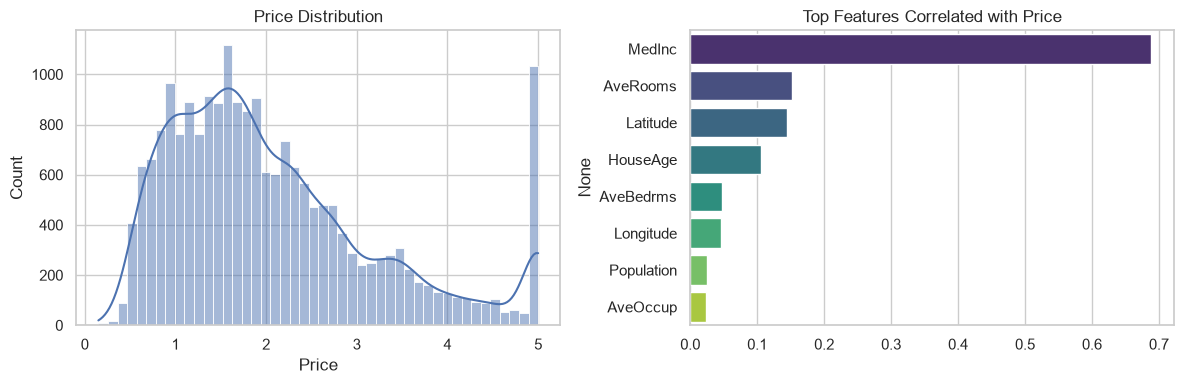

In [4]:
print('Missing values:', df.isnull().sum().sum())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
sns.histplot(df['Price'], kde=True, ax=axes[0])
axes[0].set_title('Price Distribution')

corr_with_price = df.corr(numeric_only=True)['Price'].drop('Price').abs().sort_values(ascending=False)
sns.barplot(x=corr_with_price.head(8).values, y=corr_with_price.head(8).index, ax=axes[1], palette='viridis')
axes[1].set_title('Top Features Correlated with Price')
plt.tight_layout()
plt.show()

## 3. Train Regression Models

In [5]:
X = df.drop(target_col, axis=1)
y = df[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [6]:
def evaluate_regression(name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f'{name} — MAE: {mae:.4f}, RMSE: {rmse:.4f}, R²: {r2:.4f}')
    return mae, rmse, y_pred

# Linear Regression
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
lr_mae, lr_rmse, lr_pred = evaluate_regression('Linear Regression', y_test, lr.predict(X_test_scaled))

# Gradient Boosting
gb = GradientBoostingRegressor(n_estimators=100, max_depth=4, random_state=42)
gb.fit(X_train, y_train)
gb_mae, gb_rmse, gb_pred = evaluate_regression('Gradient Boosting', y_test, gb.predict(X_test))

Linear Regression — MAE: 0.5332, RMSE: 0.7456, R²: 0.5758
Gradient Boosting — MAE: 0.3449, RMSE: 0.5095, R²: 0.8019


## 4. Predicted vs Actual — Visualization

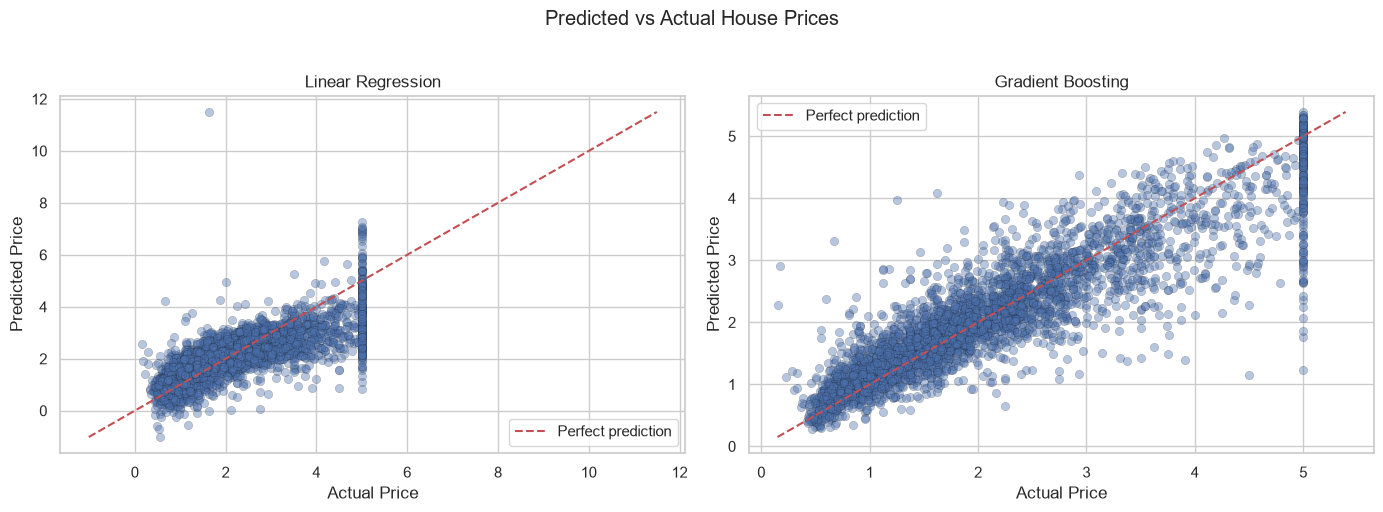

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, pred, name in zip(axes, [lr_pred, gb_pred], ['Linear Regression', 'Gradient Boosting']):
    ax.scatter(y_test, pred, alpha=0.4, edgecolors='k', linewidth=0.3)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, 'r--', label='Perfect prediction')
    ax.set_xlabel('Actual Price')
    ax.set_ylabel('Predicted Price')
    ax.set_title(name)
    ax.legend()

plt.suptitle('Predicted vs Actual House Prices', y=1.02)
plt.tight_layout()
plt.show()

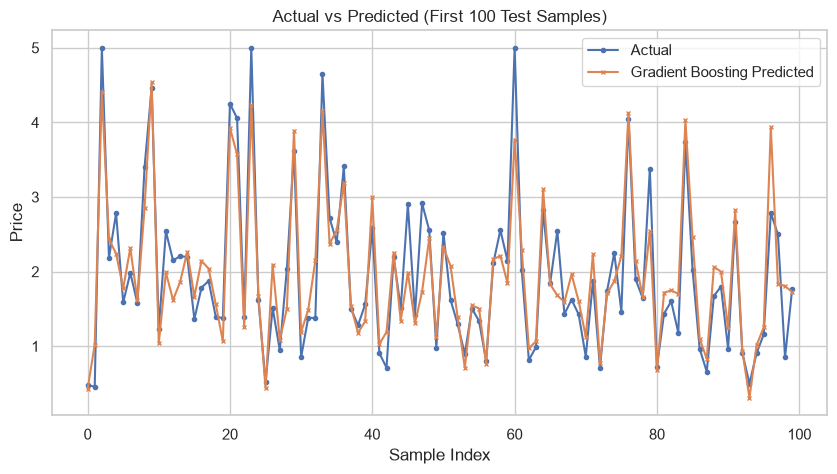

In [8]:
fig, ax = plt.subplots(figsize=(10, 5))
sample_idx = np.arange(min(100, len(y_test)))
ax.plot(sample_idx, y_test.values[:len(sample_idx)], label='Actual', marker='o', markersize=3)
ax.plot(sample_idx, gb_pred[:len(sample_idx)], label='Gradient Boosting Predicted', marker='x', markersize=3)
ax.set_xlabel('Sample Index')
ax.set_ylabel('Price')
ax.set_title('Actual vs Predicted (First 100 Test Samples)')
ax.legend()
plt.show()

## 5. Feature Importance (Gradient Boosting)

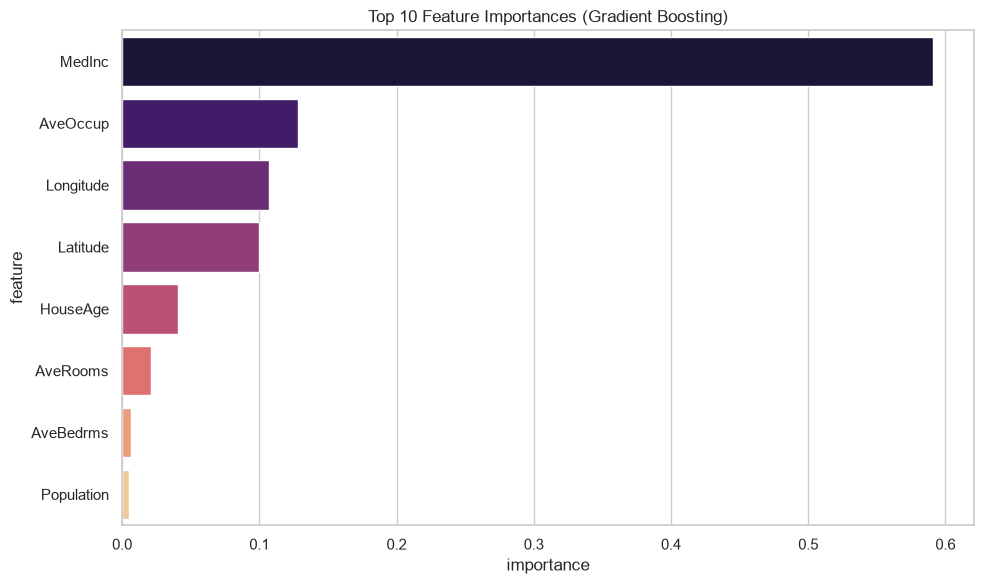

,feature,importance
0,MedInc,0.591236
5,AveOccup,0.128455
7,Longitude,0.106885
6,Latitude,0.099644
1,HouseAge,0.040947
2,AveRooms,0.021202
3,AveBedrms,0.006740
4,Population,0.004891


In [9]:
importance = pd.DataFrame({
    'feature': X.columns,
    'importance': gb.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(data=importance.head(10), y='feature', x='importance', palette='magma')
plt.title('Top 10 Feature Importances (Gradient Boosting)')
plt.tight_layout()
plt.show()
importance.head(10)

## 6. Results and Insights

- **Preprocessing:** Median imputation for missing values; StandardScaler for linear models.
- **Gradient Boosting** typically achieves lower MAE/RMSE than Linear Regression on non-linear housing data.
- **MedInc** (median income) and **AveRooms** are strong predictors in California Housing.
- For Kaggle data: download `train.csv` to `data/` folder for Ames, Iowa house prices.